In [4]:
import json
from collections import Counter
from datetime import datetime
import matplotlib.pyplot as plt

In [13]:
def load_data(json_file):
    try:
        with open(json_file, 'r', encoding='utf-8') as file:
            data = json.load(file)
    except UnicodeDecodeError:
        with open(json_file, 'r', encoding='latin-1') as file:
            data = json.load(file)
    
    filtered_data = [entry for entry in data if 'time' in entry and entry['time'].startswith("2024")]
    return filtered_data

In [25]:
def content_consumption_analysis(data):
    stop_words = {"the", "a", "an", "and", "or", "but", "is", "are", "was", "were", "to", "of", "in", "on", "at", "for", "with", "this", "that", "watched", "you", "your", "my", "it", "i", "we", "our", "from", "by", "as"}
    video_titles = [entry.get('title', 'Unknown') for entry in data]
    word_count = Counter()
    
    for title in video_titles:
        words = re.findall(r'\b\w+\b', title.lower())  # Remove symbols, keep only words
        filtered_words = [word for word in words if word not in stop_words]
        word_count.update(filtered_words)
    
    common_words = word_count.most_common(10)
    words, counts = zip(*common_words)
    
    plt.figure(figsize=(10, 5))
    plt.bar(words, counts, color='skyblue')
    plt.xlabel("Words", fontsize=12)
    plt.ylabel("Frequency", fontsize=12)
    plt.title("Most Frequent Words in Video Titles", fontsize=14)
    plt.xticks(rotation=45)
    plt.show()
    
    return common_words

In [26]:
def time_spent_analysis(data):
    timestamps = [entry['time'] for entry in data]
    times = [datetime.fromisoformat(ts.replace('Z', '+00:00')) for ts in timestamps]
    
    # Filter times for 2024 only
    times = [time for time in times if time.year == 2024]
    times_by_month = Counter([time.strftime("%Y-%m") for time in times])
    
    months, counts = zip(*sorted(times_by_month.items()))
    
    plt.figure(figsize=(10, 5))
    plt.bar(months, counts, color='orange')
    plt.xlabel("Month", fontsize=12)
    plt.ylabel("Videos Watched", fontsize=12)
    plt.title("Monthly Videos Watched in 2024", fontsize=14)
    plt.xticks(rotation=45)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()
    
    return times_by_month

In [27]:
def channel_popularity_analysis(data):
    channel_counts = Counter()
    for entry in data:
        subtitles = entry.get('subtitles', [])
        if subtitles:
            channel_name = subtitles[0].get('name', 'Unknown')
            channel_counts[channel_name] += 1
    
    most_popular_channels = channel_counts.most_common(10)
    if most_popular_channels:
        channels, counts = zip(*most_popular_channels)
        plt.figure(figsize=(10, 5))
        plt.bar(channels, counts, color='green')
        plt.xlabel("Channels", fontsize=12)
        plt.ylabel("Videos Watched", fontsize=12)
        plt.title("Most Popular Channels by Watch Count", fontsize=14)
        plt.xticks(rotation=45)
        plt.show()
    else:
        print("No channel data available for analysis.")
    
    return most_popular_channels


Running Content Consumption Analysis...


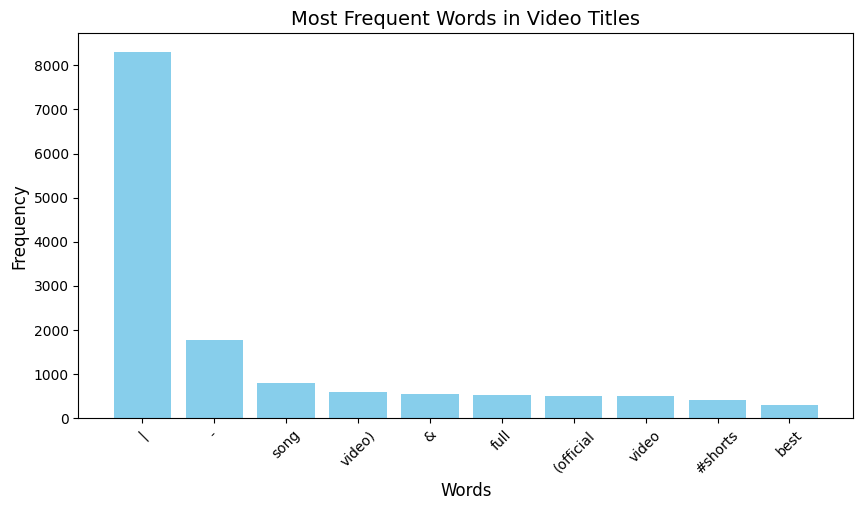

Most Common Words in Titles: [('|', 8312), ('-', 1769), ('song', 796), ('video)', 589), ('&', 540), ('full', 536), ('(official', 510), ('video', 505), ('#shorts', 425), ('best', 290)]

Running Time Spent Analysis...


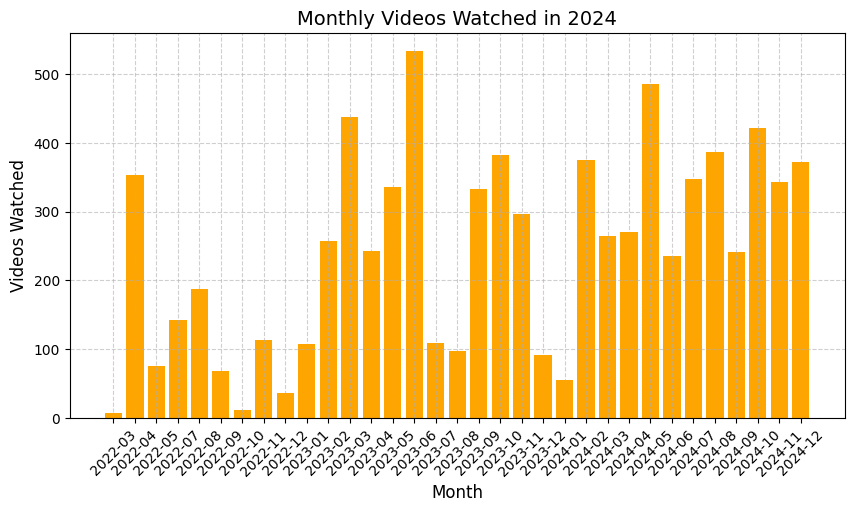

Videos Watched Per Month in 2024: Counter({'2023-06': 533, '2024-05': 486, '2023-03': 438, '2024-10': 422, '2024-08': 387, '2023-10': 383, '2024-02': 375, '2024-12': 372, '2022-04': 353, '2024-07': 348, '2024-11': 343, '2023-05': 336, '2023-09': 333, '2023-11': 297, '2024-04': 271, '2024-03': 265, '2023-02': 257, '2023-04': 243, '2024-09': 241, '2024-06': 236, '2022-08': 188, '2022-07': 142, '2022-11': 114, '2023-07': 109, '2023-01': 108, '2023-08': 98, '2023-12': 91, '2022-05': 75, '2022-09': 69, '2024-01': 56, '2022-12': 36, '2022-10': 12, '2022-03': 7})

Running Channel Popularity Analysis...


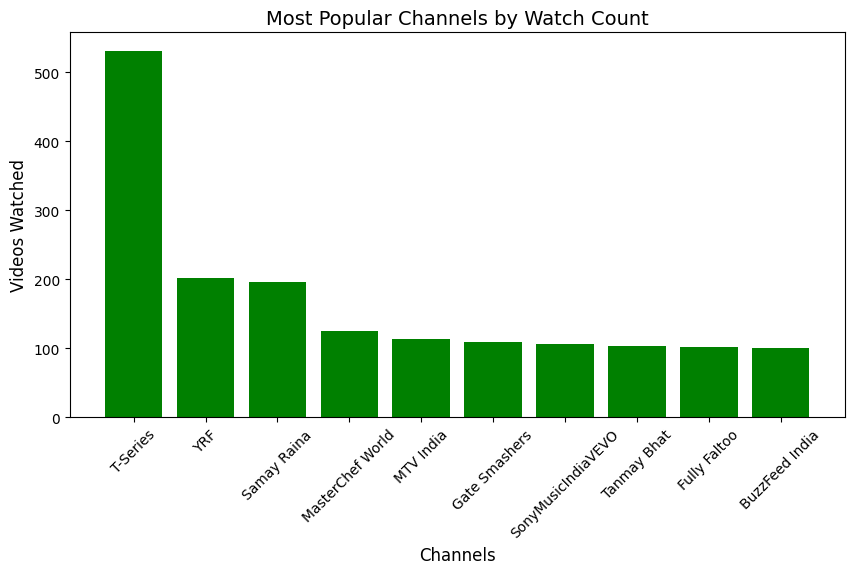

Most Popular Channels: [('T-Series', 531), ('YRF', 202), ('Samay Raina', 196), ('MasterChef World', 125), ('MTV India', 114), ('Gate Smashers', 109), ('SonyMusicIndiaVEVO', 106), ('Tanmay Bhat', 103), ('Fully Faltoo', 102), ('BuzzFeed India', 100)]


In [30]:
if __name__ == "__main__":
    json_file = "watch-history.json"  # Replace with your JSON file path
    data = load_data(json_file)

    print("\nRunning Content Consumption Analysis...")
    common_words = content_consumption_analysis(data)
    print("Most Common Words in Titles:", common_words)

    print("\nRunning Time Spent Analysis...")
    times_by_month = time_spent_analysis(data)
    print("Videos Watched Per Month in 2024:", times_by_month)

    print("\nRunning Channel Popularity Analysis...")
    popular_channels = channel_popularity_analysis(data)
    print("Most Popular Channels:", popular_channels)